# GHRSST VIIRS L2P SST - Gulf Stream (multi-granule)

Pulls ~20 VIIRS L2P swath granules over a single ocean basin via NASA Earthdata, concatenates the clear-sky pixels (>1M points after cloud masking), then fits an EFGP with hyper-parameter learning and benchmarks against SKI.

Requires: `pip install earthaccess xarray netCDF4`. The first run will prompt for your NASA Earthdata credentials.

In [16]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.optim import Adam
from efgpnd import EFGPND, _resolve_grid

sys.path.append('../../..')
from kernels import SquaredExponential, Matern
from utils.ski import fit_ski_gp
from load_ghrsst import download_ghrsst, load_ghrsst_swath, load_ghrsst_torch

In [17]:
# Download up to 20 VIIRS L2P granules over the Gulf Stream for one day.
# Skips the network call if granules are already present in ./data.
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

BBOX = (-80.0, 25.0, -60.0, 45.0)  # lon_min, lat_min, lon_max, lat_max
TARGET_GRANULES = 20

existing = sorted(DATA_DIR.glob('*VIIRS*L2P*.nc')) + sorted(DATA_DIR.glob('*VIIRS*L2P*.nc4'))
if len(existing) >= TARGET_GRANULES:
    granule_paths = existing[:TARGET_GRANULES]
    print(f'Using {len(granule_paths)} cached granules')
else:
    granule_paths = download_ghrsst(
        short_name='VIIRS_NPP-STAR-L2P-v2.80',
        temporal=('2025-06-01', '2025-06-01'),
        bounding_box=BBOX,
        count=TARGET_GRANULES,
        out_dir=DATA_DIR,
    )
    print(f'Downloaded {len(granule_paths)} granules')

for p in granule_paths[:5]:
    print(f'  {p.name}')
if len(granule_paths) > 5:
    print(f'  ... ({len(granule_paths) - 5} more)')

/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/5 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/5 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/5 [00:00<?, ?it/s]

Downloaded 5 granules
  20250601060000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc
  20250601074000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc
  20250601154000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc
  20250601172000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc
  20250601190000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc


In [18]:
# Quick preview of the first granule (just to confirm structure / units).
lon_grid, lat_grid, sst_grid, sst_meta = load_ghrsst_swath(
    path=granule_paths[0],
    variable='sea_surface_temperature',
    quality_min=5,
    to_celsius=True,
    bbox=BBOX,
)
valid_sst = np.isfinite(sst_grid)
print(f"Granule time: {sst_meta['time']}")
print(f"Title: {sst_meta['title']}")
print(f"Swath shape: {sst_grid.shape}")
print(f"Valid SST pixels: {valid_sst.sum():,} / {valid_sst.size:,}")
print(f"SST range: {np.nanmin(sst_grid):.2f} to {np.nanmax(sst_grid):.2f} {sst_meta['units']}")

Granule time: 2025-06-01T06:00:01
Title: VIIRS L2P SST
Swath shape: (5392, 3200)
Valid SST pixels: 1,208,136 / 17,254,400
SST range: 2.45 to 30.45 Celsius


In [19]:
# fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
# sst_plot = np.ma.masked_invalid(sst_grid)
# pcm = ax.pcolormesh(lon_grid, lat_grid, sst_plot, cmap='coolwarm', shading='auto', rasterized=True)
# ax.set_title(f"VIIRS L2P SST (single swath) {sst_meta['time']}")
# ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
# ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
# ax.grid(alpha=0.2)
# plt.colorbar(pcm, ax=ax, label=f"SST ({sst_meta['units']})")

In [20]:
# Concatenate clear-sky pixels across ALL granules.
x, y = load_ghrsst_torch(
    path=granule_paths,
    variable='sea_surface_temperature',
    quality_min=5,
    to_celsius=True,
    bbox=BBOX,
    n_sub=None,   # set e.g. 2_000_000 to cap
    seed=0,
)
print(f'x shape: {tuple(x.shape)}')
print(f'y shape: {tuple(y.shape)}')
print(f'Lon range: {x[:, 0].min():.3f} to {x[:, 0].max():.3f}')
print(f'Lat range: {x[:, 1].min():.3f} to {x[:, 1].max():.3f}')
print(f"SST range: {y.min():.2f} to {y.max():.2f} {sst_meta['units']}")

x shape: (3282924, 2)
y shape: (3282924,)
Lon range: -80.000 to -60.000
Lat range: 25.000 to 45.000
SST range: 2.45 to 30.76 Celsius


Text(0.5, 0.98, 'VIIRS L2P SST clear-sky pixels — 5 granules over Gulf Stream')

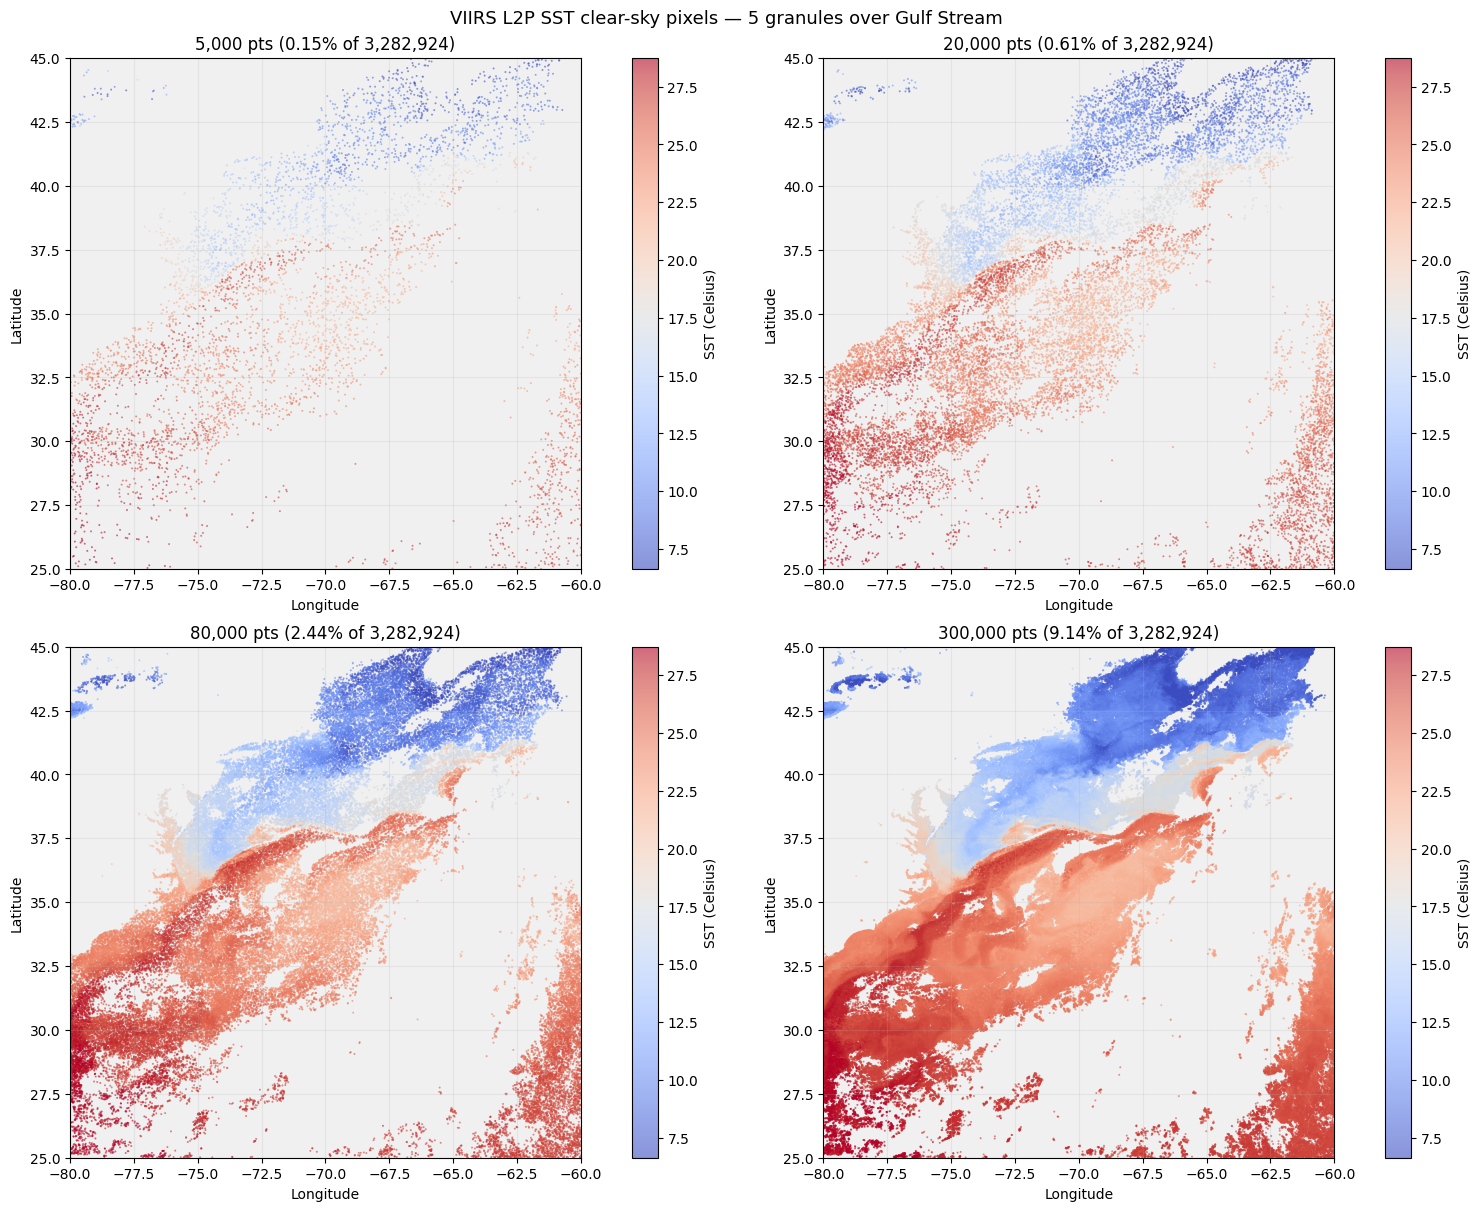

In [21]:
# Visualise the data at a few subsampling rates — too many points and you
# just see a coloured rectangle, too few and you miss the structure.
rng = np.random.default_rng(0)
sample_sizes = [5_000, 20_000, 80_000, 300_000]
vmin = float(np.nanpercentile(y.numpy(), 1))
vmax = float(np.nanpercentile(y.numpy(), 99))

fig, axes = plt.subplots(2, 2, figsize=(15, 12), constrained_layout=True)
for ax, n_plot in zip(axes.ravel(), sample_sizes):
    n = min(n_plot, len(y))
    idx = rng.choice(len(y), size=n, replace=False)
    ax.set_facecolor('#f0f0f0')
    sc = ax.scatter(
        x[idx, 0].numpy(), x[idx, 1].numpy(),
        c=y[idx].numpy(), s=2.0, cmap='coolwarm', alpha=0.6,
        vmin=vmin, vmax=vmax, linewidths=0, rasterized=True,
    )
    frac = n / len(y) * 100
    ax.set_title(f'{n:,} pts ({frac:.2f}% of {len(y):,})')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)
    fig.colorbar(sc, ax=ax, label=f"SST ({sst_meta['units']})")
fig.suptitle(f'VIIRS L2P SST clear-sky pixels — {len(granule_paths)} granules over Gulf Stream', fontsize=13)

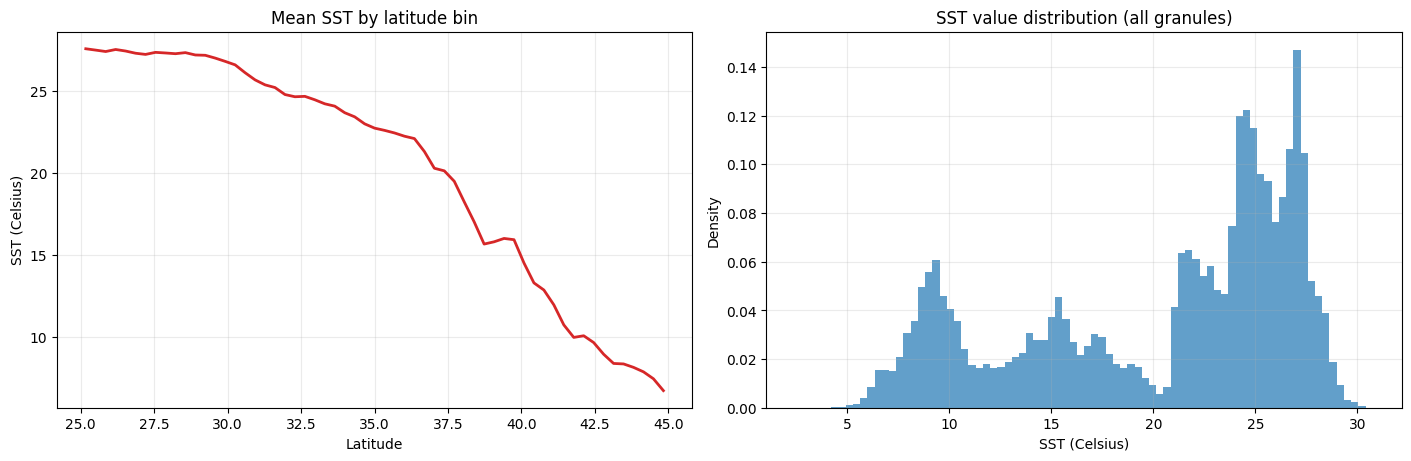

In [22]:
# Distribution + lat-binned mean from the merged point cloud.
y_np = y.numpy()
lat_np = x[:, 1].numpy()
lat_bins = np.linspace(BBOX[1], BBOX[3], 60)
lat_mid = 0.5 * (lat_bins[:-1] + lat_bins[1:])
lat_mean = np.array([
    y_np[(lat_np >= lo) & (lat_np < hi)].mean() if ((lat_np >= lo) & (lat_np < hi)).any() else np.nan
    for lo, hi in zip(lat_bins[:-1], lat_bins[1:])
])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
axes[0].plot(lat_mid, lat_mean, color='tab:red', linewidth=2)
axes[0].set_title('Mean SST by latitude bin')
axes[0].set_xlabel('Latitude'); axes[0].set_ylabel(f"SST ({sst_meta['units']})"); axes[0].grid(alpha=0.25)

axes[1].hist(y_np, bins=80, density=True, alpha=0.7, color='tab:blue')
axes[1].set_title('SST value distribution (all granules)')
axes[1].set_xlabel(f"SST ({sst_meta['units']})"); axes[1].set_ylabel('Density'); axes[1].grid(alpha=0.25)

In [23]:
# Normalize inputs to [0, 1] and standardize outputs (same convention as OISST notebook).
x_min, x_max = x.min(dim=0).values, x.max(dim=0).values
x = (x - x_min) / (x_max - x_min)

y_mean, y_std = y.mean(), y.std()
y = (y - y_mean) / y_std

print(f'x range per dim: {x.min(dim=0).values.tolist()} to {x.max(dim=0).values.tolist()}')
print(f'y mean={y.mean():.4f}, std={y.std():.4f}')

x = x.to(dtype=torch.float32)
y = y.to(dtype=torch.float32)

x range per dim: [0.0, 0.0] to [1.0, 1.0]
y mean=0.0000, std=1.0000


In [24]:
d = x.shape[1]
EPSILON = 1e-3
cg_tol = 1e-4
noise_floor = 1e-4

init_ls = 0.1
init_var = 1.0
init_noise = 1.0

kernel_efgp = SquaredExponential(
    dimension=d, init_lengthscale=init_ls, init_variance=init_var
)
# kernel_efgp = Matern(
#     dimension=d, init_lengthscale=init_ls, init_variance=init_var, nu=1.5
# )
print(f'N = {x.shape[0]:,}, d = {d}')

N = 3,282,924, d = 2


In [25]:
max_iters = 50
REFRESH_EVERY = 10
J = 1

training_log = {
    'iter': [], 'lengthscale': [], 'variance': [], 'sigmasq': [],
    'mean_cg_iters': [], 'trace_cg_iters': [], 'mtot': [], 'feature_count': [],
    'wall_sec': [], 'grid_refreshed': [],
}

# trace_cg_warm_start and trace_probes_freeze are on by default in EFGPND;
# they pair with REFRESH_EVERY to give the trace solve its warm start.
model = EFGPND(
    x, y, kernel=kernel_efgp, sigmasq=init_noise, eps=EPSILON,
    estimate_params=False,
    opts={"mean_cg_preconditioner_type": "jacobi"},
    # opts={"mean_cg_preconditioner_type": "kronecker"},
)
optimizer = Adam(model.parameters(), lr=0.2)

training_log['iter'].append(0)
training_log['lengthscale'].append(model.kernel.get_hyper('lengthscale'))
training_log['variance'].append(model.kernel.get_hyper('variance'))
training_log['sigmasq'].append(model._gp_params.sig2.item())
for k in ('mean_cg_iters', 'trace_cg_iters', 'mtot', 'feature_count', 'wall_sec', 'grid_refreshed'):
    training_log[k].append(None)

import time as _time

frozen_grid = None
for it in range(max_iters):
    # Rebuild frozen_grid from the *current* hypers every REFRESH_EVERY iters.
    # On all other iters, reuse the previous (xis_1d_list, h_per_dim) so M is
    # stable and the cached mean/trace betas + frozen Hutchinson probes apply.
    if REFRESH_EVERY and it % REFRESH_EVERY == 0:
        xis_1d_list, h_per_dim, _, _ = _resolve_grid(
            model.kernel, model.x, EPSILON,
            rdtype=model.x.dtype, device=model.x.device,
        )
        frozen_grid = (xis_1d_list, h_per_dim)
        refreshed = True
    else:
        refreshed = False

    t0 = _time.perf_counter()
    optimizer.zero_grad()
    model.compute_gradients(
        trace_samples=J, cg_tol=cg_tol, noise_floor=noise_floor,
        frozen_grid=frozen_grid,
    )
    optimizer.step()
    dt = _time.perf_counter() - t0

    stats = model.last_gradient_stats
    mean_cg_iters = stats.get('mean_cg_iters')
    trace_cg_iters = stats.get('trace_cg_iters')
    mtot = stats.get('mtot')
    feature_count = stats.get('feature_count')

    lengthscale = model.kernel.get_hyper('lengthscale')
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it + 1)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)
    training_log['mean_cg_iters'].append(mean_cg_iters)
    training_log['trace_cg_iters'].append(trace_cg_iters)
    training_log['mtot'].append(mtot)
    training_log['feature_count'].append(feature_count)
    training_log['wall_sec'].append(dt)
    training_log['grid_refreshed'].append(refreshed)

    # Print every iter so the warm-start (non-refresh) iters are visible.
    # The leading "*" marks iters where the grid was rebuilt.
    flag = '*' if refreshed else ' '
    print(
        f"{flag} iter {it+1:>3}  {dt:5.2f}s  "
        f"ℓ={lengthscale:.4g}  σ_f²={variance:.4g}  σ_n²={sigmasq:.4g}  "
        f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}  mtot={mtot}  M={feature_count}"
    )

print(
    f"\nFinal: ℓ={lengthscale:.4g}, σ_f²={variance:.4g}, σ_n²={sigmasq:.4g}, "
    f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}, mtot={mtot}, M={feature_count}"
)
walls = [w for w in training_log['wall_sec'] if w is not None]
refresh_walls = [w for w, r in zip(walls, training_log['grid_refreshed'][1:]) if r]
warm_walls = [w for w, r in zip(walls, training_log['grid_refreshed'][1:]) if not r]
print(f"Total wall: {sum(walls):.1f}s")
if refresh_walls and warm_walls:
    print(f"  refresh iters (n={len(refresh_walls)}): mean {sum(refresh_walls)/len(refresh_walls):.2f}s")
    print(f"  warm iters    (n={len(warm_walls)}): mean {sum(warm_walls)/len(warm_walls):.2f}s")

* iter   1   0.14s  ℓ=0.0826  σ_f²=1.131  σ_n²=0.8783  cg(mean/trace)=177/121  mtot=21  M=441
  iter   2   0.03s  ℓ=0.06862  σ_f²=1.267  σ_n²=0.7662  cg(mean/trace)=232/80  mtot=21  M=441
  iter   3   0.03s  ℓ=0.05816  σ_f²=1.402  σ_n²=0.6639  cg(mean/trace)=223/94  mtot=21  M=441
  iter   4   0.03s  ℓ=0.05035  σ_f²=1.53  σ_n²=0.5714  cg(mean/trace)=218/94  mtot=21  M=441
  iter   5   0.04s  ℓ=0.04436  σ_f²=1.656  σ_n²=0.4887  cg(mean/trace)=265/137  mtot=21  M=441
  iter   6   0.02s  ℓ=0.03968  σ_f²=1.777  σ_n²=0.4153  cg(mean/trace)=124/74  mtot=21  M=441
  iter   7   0.04s  ℓ=0.03594  σ_f²=1.899  σ_n²=0.351  cg(mean/trace)=264/137  mtot=21  M=441
  iter   8   0.02s  ℓ=0.03292  σ_f²=2.022  σ_n²=0.295  cg(mean/trace)=90/75  mtot=21  M=441
  iter   9   0.03s  ℓ=0.03045  σ_f²=2.144  σ_n²=0.2467  cg(mean/trace)=101/137  mtot=21  M=441
  iter  10   0.02s  ℓ=0.02842  σ_f²=2.266  σ_n²=0.2055  cg(mean/trace)=56/70  mtot=21  M=441
* iter  11   0.20s  ℓ=0.02584  σ_f²=2.388  σ_n²=0.1704  cg(mea

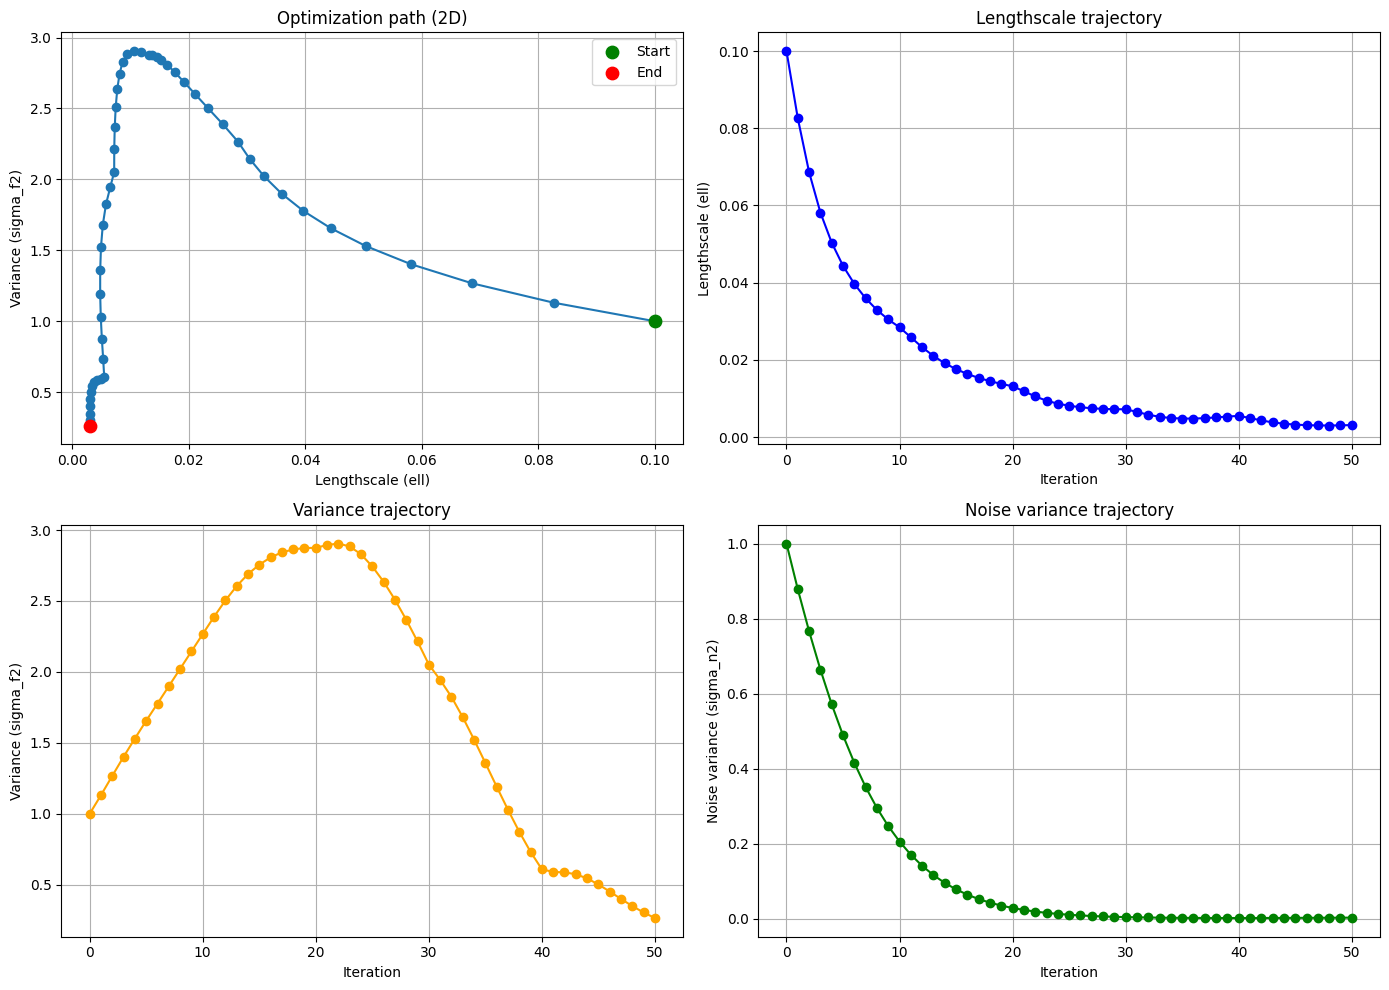

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.plot(training_log['lengthscale'], training_log['variance'], 'o-')
ax1.scatter(training_log['lengthscale'][0], training_log['variance'][0], color='green', s=80, label='Start', zorder=5)
ax1.scatter(training_log['lengthscale'][-1], training_log['variance'][-1], color='red', s=80, label='End', zorder=5)
ax1.set_xlabel('Lengthscale (ell)'); ax1.set_ylabel('Variance (sigma_f2)')
ax1.set_title('Optimization path (2D)'); ax1.legend(); ax1.grid(True)

axes[0, 1].plot(training_log['iter'], training_log['lengthscale'], 'o-', color='blue')
axes[0, 1].set_xlabel('Iteration'); axes[0, 1].set_ylabel('Lengthscale (ell)')
axes[0, 1].set_title('Lengthscale trajectory'); axes[0, 1].grid(True)

axes[1, 0].plot(training_log['iter'], training_log['variance'], 'o-', color='orange')
axes[1, 0].set_xlabel('Iteration'); axes[1, 0].set_ylabel('Variance (sigma_f2)')
axes[1, 0].set_title('Variance trajectory'); axes[1, 0].grid(True)

axes[1, 1].plot(training_log['iter'], training_log['sigmasq'], 'o-', color='green')
axes[1, 1].set_xlabel('Iteration'); axes[1, 1].set_ylabel('Noise variance (sigma_n2)')
axes[1, 1].set_title('Noise variance trajectory'); axes[1, 1].grid(True)
plt.tight_layout()

## Posterior inference & uncertainty quantification

Predict the EFGP posterior over the Gulf Stream region with the learned hyper-parameters. We map the **posterior mean** SST, then quantify uncertainty with the **pathwise (Matheron)** estimator (`model.predict_pathwise`), which draws posterior functions via smooth-RHS mean solves — fast, non-negative, and it returns the draws themselves. The slower broadband **stochastic (Hutchinson)** estimator is kept at the end as an *optional* comparison.

The mean is masked outside the VIIRS clear-sky footprint; the **variance is left unmasked on purpose**, so you can see the posterior variance rise back to the prior variance away from data.

In [27]:
# ---- Posterior mean over the Gulf Stream region ----
import cartopy.crs as ccrs
import cartopy.feature as cfeature
PC = ccrs.PlateCarree()

def add_coast(ax):
    """Land fill + 50m coastline outline, cropped to BBOX, with lon/lat gridline labels."""
    ax.set_facecolor('#f0f0f0')
    ax.add_feature(cfeature.LAND, facecolor='#cfcfcf', edgecolor='none', zorder=2)
    ax.coastlines(resolution='50m', linewidth=0.6, color='0.3', zorder=3)
    ax.set_extent([BBOX[0], BBOX[2], BBOX[1], BBOX[3]], crs=PC)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='0.8', alpha=0.5)
    gl.top_labels = gl.right_labels = False

# Dense lon/lat grid in the normalized [0, 1] coords used for training.
grid_res = 500
g = torch.linspace(0, 1, grid_res, dtype=x.dtype)
G_LON, G_LAT = torch.meshgrid(g, g, indexing='ij')
x_new = torch.stack([G_LON.flatten(), G_LAT.flatten()], dim=1).to(dtype=x.dtype)

# Posterior mean (fast: one CG beta-solve + a single NUFFT).
mean_pred = model.predict(x_new=x_new, return_variance=False)
mean_pred = mean_pred[0] if isinstance(mean_pred, tuple) else mean_pred
mean_grid = (mean_pred.detach().cpu() * y_std + y_mean).numpy().reshape(grid_res, grid_res)

# Physical lon/lat for plotting (un-normalize the grid).
lon_pred = G_LON.numpy() * (x_max[0] - x_min[0]).item() + x_min[0].item()
lat_pred = G_LAT.numpy() * (x_max[1] - x_min[1]).item() + x_min[1].item()

# Data-footprint mask: VIIRS clear-sky pixels are a point cloud (land + clouds leave gaps).
# We mask the *mean* outside the footprint; the variance map below is left unmasked.
edges = np.linspace(0, 1, grid_res + 1)
counts, _, _ = np.histogram2d(x[:, 0].numpy(), x[:, 1].numpy(), bins=[edges, edges])
covered = counts > 0
try:
    from scipy.ndimage import binary_dilation
    covered = binary_dilation(covered, iterations=2)
except Exception:
    pass
mean_masked = np.ma.masked_where(~covered, mean_grid)

print(f'Posterior mean on {x_new.shape[0]:,} grid points ({grid_res}x{grid_res}); '
      f'{covered.sum():,} cells inside the data footprint')

Posterior mean on 250,000 grid points (500x500); 140,286 cells inside the data footprint


Text(0.5, 0.98, 'ℓ=0.003102,  σ_f²=0.265,  σ_n²=0.0026')

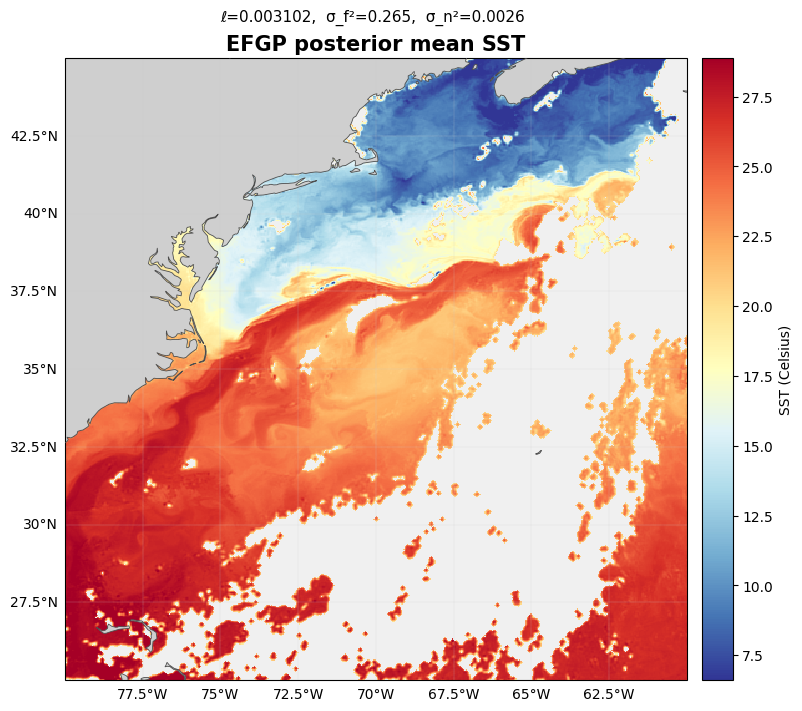

In [28]:
# ---- Posterior mean map ----
ell = model.kernel.get_hyper('lengthscale')
sf2 = model.kernel.get_hyper('variance')
sn2 = model._gp_params.sig2.item()

fig, ax = plt.subplots(figsize=(8.5, 7), subplot_kw={'projection': PC}, constrained_layout=True)
pcm = ax.pcolormesh(lon_pred, lat_pred, mean_masked, cmap='RdYlBu_r', shading='auto', rasterized=True,
                    transform=PC, vmin=np.percentile(mean_masked.compressed(), 1),
                    vmax=np.percentile(mean_masked.compressed(), 99))
add_coast(ax)
ax.set_title('EFGP posterior mean SST', fontsize=15, fontweight='bold')
fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.02).set_label(f"SST ({sst_meta['units']})")
fig.suptitle(f'ℓ={ell:.4g},  σ_f²={sf2:.3g},  σ_n²={sn2:.3g}', fontsize=11)

### Pathwise (Matheron) UQ — the default variance estimator

Draw posterior functions via Matheron's rule; each draw needs only a smooth-RHS *mean* solve, so it converges in mean-like CG iterations (vs. the broadband √κ blow-up of the diagonal-sums estimator at small σ²). The variance is the empirical variance of the draws — non-negative by construction — and we get the draws for free. Tune `n_samples` for the Monte-Carlo accuracy/speed trade-off (cost is ~linear in `n_samples`).

The std map is **not masked**: away from the data the posterior variance climbs back to the prior variance, and the colour scale is capped at the prior std so that plateau is explicit.

pathwise UQ: 235.7s for 64 samples on 250,000 grid pts
prior std = 3.43 Celsius  (posterior std saturates here off-data)


Text(0.5, 0.98, 'Pathwise (Matheron) UQ over the Gulf Stream  (n_samples=64)')

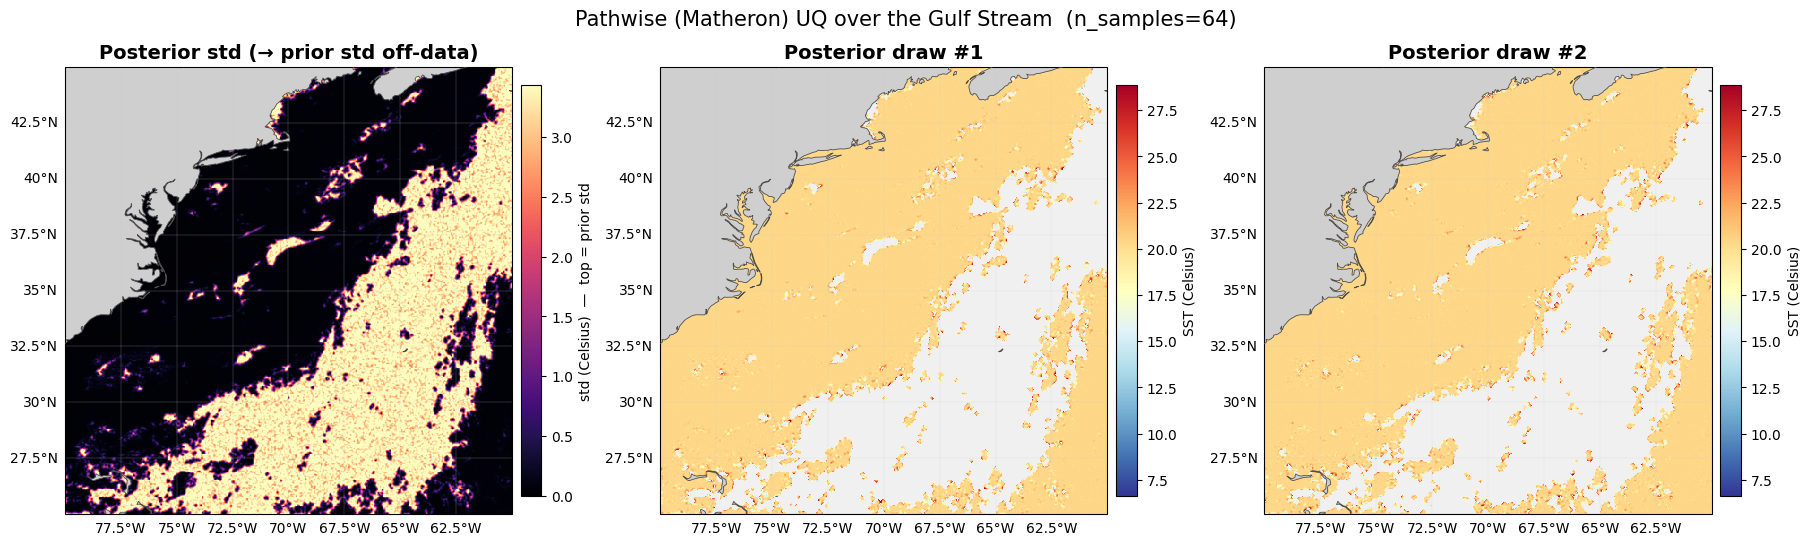

In [29]:
# ---- Pathwise (Matheron) UQ: posterior std + free posterior draws ----
# var is the empirical variance of n_samples posterior draws; each draw is a smooth-RHS
# mean solve. See ../../../scratch/pathwise_variance.tex.
import time as _time

n_samples = 8
t0 = _time.perf_counter()
var_path, samples = model.predict_pathwise(x_new, n_samples=n_samples, return_samples=True, seed=0)
print(f'pathwise UQ: {_time.perf_counter()-t0:.1f}s for {n_samples} samples on {x_new.shape[0]:,} grid pts')

# Posterior std in physical units -- NOT masked: away from data it rises to the prior std.
std_path = (var_path.detach().cpu().clamp_min(0).sqrt() * y_std).numpy().reshape(grid_res, grid_res)
prior_std = float(model.kernel.get_hyper('variance')) ** 0.5 * float(y_std)   # sqrt(σ_f²)·y_std
print(f"prior std = {prior_std:.2f} {sst_meta['units']}  (posterior std saturates here off-data)")

# Two example posterior draws (masked to the footprint, in physical units).
draws = [np.ma.masked_where(~covered, (samples[s].detach().cpu() * y_std + y_mean)
                            .numpy().reshape(grid_res, grid_res)) for s in (0, 1)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.4), subplot_kw={'projection': PC}, constrained_layout=True)
ax = axes[0]
pcm = ax.pcolormesh(lon_pred, lat_pred, std_path, cmap='magma', shading='auto', rasterized=True,
                    transform=PC, vmin=0.0, vmax=prior_std)   # cap at prior std -> gaps saturate at the prior
add_coast(ax)
ax.set_title('Posterior std (→ prior std off-data)', fontsize=14, fontweight='bold')
cb = fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.02)
cb.set_label(f"std ({sst_meta['units']})  —  top = prior std")
for ax, dr, s in zip(axes[1:], draws, (0, 1)):
    pcm = ax.pcolormesh(lon_pred, lat_pred, dr, cmap='RdYlBu_r', shading='auto', rasterized=True,
                        transform=PC, vmin=np.percentile(mean_masked.compressed(), 1),
                        vmax=np.percentile(mean_masked.compressed(), 99))
    add_coast(ax)
    ax.set_title(f'Posterior draw #{s+1}', fontsize=14, fontweight='bold')
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.02).set_label(f"SST ({sst_meta['units']})")
fig.suptitle(f'Pathwise (Matheron) UQ over the Gulf Stream  (n_samples={n_samples})', fontsize=15)
# fig.savefig('ghrsst_pathwise_uq.png', dpi=200, bbox_inches='tight')

### (optional) Stochastic Hutchinson estimator — slow, for comparison

The original broadband diagonal-sums estimator (`variance_method='stochastic'`). Accurate, but its CG cost grows like √κ as σ² shrinks, so on the full grid it can take minutes. Off by default — set `RUN_HUTCHINSON = True` to run it and compare against the pathwise std on the same colour scale.

In [30]:
# ---- (optional) stochastic Hutchinson variance, for comparison ----
# The broadband diagonal-sums estimator: accurate but its CG cost grows ~sqrt(kappa) as the
# noise shrinks, so on the full grid it can take minutes. Off by default.
RUN_HUTCHINSON = False

if RUN_HUTCHINSON:
    t0 = _time.perf_counter()
    _, var_stoch = model.predict(x_new=x_new, return_variance=True,
                                 variance_method='stochastic', hutchinson_probes=64)
    print(f'Hutchinson UQ: {_time.perf_counter()-t0:.1f}s')
    std_stoch = (var_stoch.detach().cpu().clamp_min(0).sqrt() * y_std).numpy().reshape(grid_res, grid_res)

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6), subplot_kw={'projection': PC}, constrained_layout=True)
    for ax, fld, ttl in [(axes[0], std_path, 'pathwise'), (axes[1], std_stoch, 'Hutchinson')]:
        pcm = ax.pcolormesh(lon_pred, lat_pred, fld, cmap='magma', shading='auto',
                            rasterized=True, transform=PC, vmin=0.0, vmax=prior_std)
        add_coast(ax)
        ax.set_title(f'Posterior std — {ttl}', fontsize=14, fontweight='bold')
        fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.02).set_label(f"std ({sst_meta['units']})")
else:
    print('Hutchinson comparison skipped (set RUN_HUTCHINSON = True to run; can take minutes).')

Hutchinson comparison skipped (set RUN_HUTCHINSON = True to run; can take minutes).
